### CNN model with the Mel spectogram (basically redoing 04_keira_simple_cnn.ipynb)

In [1]:
import os
from pathlib import Path
import sys

# Move notebook working directory to the project root
os.chdir("/home/sunil/code/mi-mi-mia/smart-stethoscope")

# Make sure Python can import the package
sys.path.insert(0, str(Path.cwd()))

print("Current working directory:", Path.cwd())
print("raw_data exists:", Path("raw_data").exists())
print("preprocessed_data exists:", Path("preprocessed_data").exists())

Current working directory: /home/sunil/code/mi-mi-mia/smart-stethoscope
raw_data exists: True
preprocessed_data exists: True


In [2]:
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from smart_stethoscope.ml_logic.data_loading import load_data
from smart_stethoscope.ml_logic.preprocessing import (

    preprocess_tabular_data
)
from smart_stethoscope.ml_logic.model import run_logistic_baseline

I0000 00:00:1774274649.482177  140742 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774274650.300742  140742 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774274653.240427  140742 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [6]:
df = load_data()

df.shape


✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...


(6898, 13)

In [7]:
df.head()

,start,end,crackles,wheezes,filename,chest_location,cycle_filename,disease,age,sex,adult_bmi,child_weight,child_height
0,1.377,4.249,1,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_0,COPD,73.0,M,29.3,NaN,NaN
1,4.249,7.387,1,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_1,COPD,73.0,M,29.3,NaN,NaN
2,7.387,10.175,1,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_2,COPD,73.0,M,29.3,NaN,NaN
3,10.175,12.897,0,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_3,COPD,73.0,M,29.3,NaN,NaN
4,12.897,15.634,0,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_4,COPD,73.0,M,29.3,NaN,NaN


In [9]:
X_train_tab, X_val_tab, X_test_tab, y_train, y_val, y_test, train_cycle_filenames, val_cycle_filenames, test_cycle_filenames = preprocess_tabular_data(df)

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [10]:
train_cycle_filenames

array(['172_2b5_Pl_mc_AKGC417L_0', '172_2b5_Pl_mc_AKGC417L_1',
       '172_2b5_Pl_mc_AKGC417L_2', ..., '107_2b5_Pl_mc_AKGC417L_5',
       '107_2b5_Pl_mc_AKGC417L_6', '107_2b5_Pl_mc_AKGC417L_7'],
      shape=(4889,), dtype=object)

In [11]:
cycle_audio_path = "preprocessed_data/padded_audio_breathing_cycles"


In [12]:
file_path = Path(cycle_audio_path) / f"{train_cycle_filenames[0]}.wav"

signal, sample_rate = librosa.load(file_path, sr=None)

mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        #n_mfcc=n_mfcc
        )

mfcc

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[-3.68777985e+02, -3.46086823e+02, -3.45726349e+02, ...,
        -5.00092194e+02, -5.00092194e+02, -5.00092194e+02],
       [ 9.59337616e+01,  9.72527847e+01,  1.00239929e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.09331245e+01,  4.74489937e+01,  5.17517319e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.20838106e-01,  5.20789909e+00,  5.96529961e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.01210928e+00,  1.03282297e+00,  3.29809952e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.10824299e+00,  2.58854556e+00,  4.29487610e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(20, 259), dtype=float32)

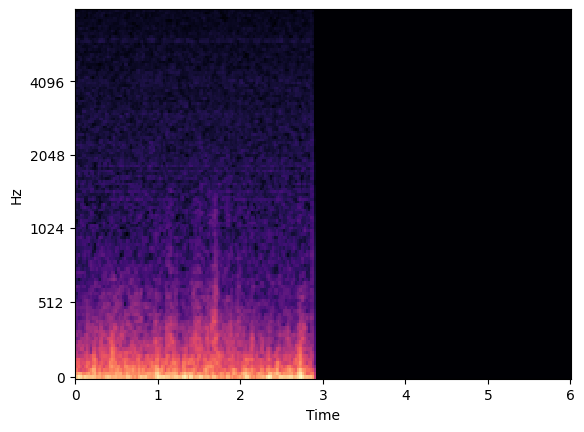

In [13]:
S = librosa.feature.melspectrogram(y=signal, sr=sample_rate, n_mels=128,
                                   fmax=8000)

#
#fig, ax = plt.subplots(nrows=2, sharex=True)
img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=8000,
                               )
#fig.colorbar(img)
#ax[0].set(title='Mel spectrogram')
#ax[0].label_outer()
img

In [14]:
# Define a function to transform wav file to a mel spectrogram

def wav_to_mel_spec(
    cycle_filename,
    audio_folder,
    n_mels=64,
    max_time_steps=200
):

    """
    Convert one breathing cycle .wav file into a fixed-size mel spectrogram.

    Parameters
    ----------
    cycle_filename : str
        Breathing cycle filename without the .wav extension.
        Example: '101_1b1_Al_sc_Meditron_0'
    audio_folder : str or Path
        Folder containing extracted breathing cycle .wav files.
    n_mels : int, default=64
        Number of mel frequency bins.
    max_time_steps : int, default=200
        Fixed width for the spectrogram.
        If spectrogram is shorter, pad with zeros.
        If longer, crop.

    Returns
    -------
    mel_spec_db : np.ndarray
        2D array of shape (n_mels, max_time_steps)
    """

    # Build full file path
    file_path = Path(audio_folder) / f"{cycle_filename}.wav"

    # Load audio at original sample rate
    signal, sr = librosa.load(file_path, sr=None)

    # Convert waveform to mel spectrogram (power scale)
    mel_spec = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=n_mels
    )

    # Convert to decibel scale for better modelling / visualisation
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Current shape is (n_mels, time_steps)
    current_time_steps = mel_spec_db.shape[1]

    # Pad with zeros on the right if too short
    if current_time_steps < max_time_steps:
        pad_width = max_time_steps - current_time_steps
        mel_spec_db = np.pad(
            mel_spec_db,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )

    # Crop on the right if too long
    elif current_time_steps > max_time_steps:
        mel_spec_db = mel_spec_db[:, :max_time_steps]

    return mel_spec_db

In [15]:
example_cycle = train_cycle_filenames[0]
example_mel = wav_to_mel_spec(
    cycle_filename=example_cycle,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

print("Mel spectrogram shape:", example_mel.shape)

Mel spectrogram shape: (64, 200)


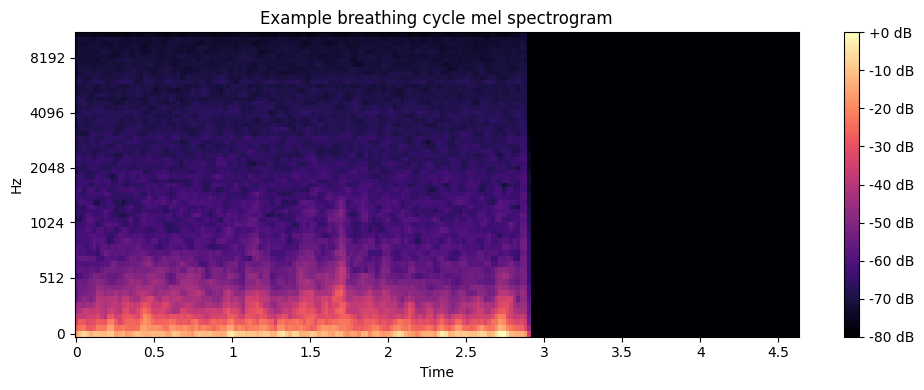

In [16]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    example_mel,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Example breathing cycle mel spectrogram")
plt.tight_layout()
plt.show()

In [17]:
# Assumes these already exist from previous steps:
# - train_cycle_filenames
# - test_cycle_filenames
# - wav_to_mel_spec()
# - cycle_audio_path

def build_mel_dataset(
    cycle_filenames,
    audio_folder,
    n_mels=64,
    max_time_steps=200):
    """
    Convert a list/array of cycle filenames into a 4D tensor for CNN input.

    Parameters
    ----------
    cycle_filenames : iterable of str
        Cycle filenames without .wav extension
    audio_folder : str or Path
        Folder containing cycle .wav files
    n_mels : int, default=64
        Number of mel bins
    max_time_steps : int, default=200
        Fixed spectrogram width

    Returns
    -------
    X : np.ndarray
        CNN-ready tensor of shape (n_samples, n_mels, max_time_steps, 1)
    """

    mel_specs = []

    for cycle_filename in cycle_filenames:
        # convert each wav to a mel spec
        mel = wav_to_mel_spec(
            cycle_filename=cycle_filename,
            audio_folder=audio_folder,
            n_mels=n_mels,
            max_time_steps=max_time_steps
        )
        # add each 2D array to the list
        mel_specs.append(mel)

    # Stack into one 3D array: (n_samples, n_mels, max_time_steps)
    X = np.stack(mel_specs)

    # Add channel dimension for expected CNN shape: (n_samples, n_mels, max_time_steps, 1)
    X = X[..., np.newaxis]

    return X

In [ ]:
# Build train and test image tensors
cycle_audio_path = "preprocessed_data/audio_breathing_cycles"

X_train_img = build_mel_dataset(
    cycle_filenames=train_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)
X_val_img = build_mel_dataset(
    cycle_filenames=val_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

X_test_img = build_mel_dataset(
    cycle_filenames=test_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

print("X_train_img shape:", X_train_img.shape)
print("X_train_img shape:", X_val_img.shape)
print("X_test_img shape:", X_test_img.shape)
print("Expected CNN input shape per sample:", X_train_img[0].shape)

X_train_img shape: (4889, 64, 200, 1)
X_train_img shape: (917, 64, 200, 1)
X_test_img shape: (1054, 64, 200, 1)
Expected CNN input shape per sample: (64, 200, 1)


In [19]:
y_train.value_counts()

disease
1    4085
4     228
0     212
2     167
5     128
3      69
Name: count, dtype: int64

trying two categories to see what happens

In [20]:
y_train_red = y_train.replace({2:1, 3:1, 4:1, 5:1})
y_train_red.value_counts()/y_train_red.size

disease
1    0.956637
0    0.043363
Name: count, dtype: float64

In [21]:
y_test_red = y_test.replace({2:1, 3:1, 4:1, 5:1})
y_test_red.value_counts()/y_test_red.size

disease
1    0.94592
0    0.05408
Name: count, dtype: float64

In [22]:
y_val_red = y_val.replace({2:1, 3:1, 4:1, 5:1})
y_val_red.value_counts()/y_val_red.size

disease
1    0.942203
0    0.057797
Name: count, dtype: float64

In [23]:
from tensorflow.keras.utils import to_categorical

In [24]:
y_train_red_cat = to_categorical(y_train_red)
y_test_red_cat = to_categorical(y_test_red)
y_val_red_cat = to_categorical(y_val_red)

In [25]:
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)
y_val_cat = to_categorical(y_val,  num_classes=num_classes)


In [26]:
y_train_red_cat.shape

(4889, 2)

In [27]:
X_train_img[0]

array([[[-17.724575],
        [ -9.440346],
        [ -4.6432  ],
        ...,
        [  0.      ],
        [  0.      ],
        [  0.      ]],

       [[-22.51104 ],
        [-18.613722],
        [-19.0711  ],
        ...,
        [  0.      ],
        [  0.      ],
        [  0.      ]],

       [[-30.116325],
        [-27.23895 ],
        [-25.710104],
        ...,
        [  0.      ],
        [  0.      ],
        [  0.      ]],

       ...,

       [[-78.11417 ],
        [-75.77949 ],
        [-75.63925 ],
        ...,
        [  0.      ],
        [  0.      ],
        [  0.      ]],

       [[-77.269226],
        [-74.97612 ],
        [-74.96226 ],
        ...,
        [  0.      ],
        [  0.      ],
        [  0.      ]],

       [[-78.23955 ],
        [-76.972115],
        [-77.216156],
        ...,
        [  0.      ],
        [  0.      ],
        [  0.      ]]], shape=(64, 200, 1), dtype=float32)

In [28]:
import tensorflow
from tensorflow.keras import layers, Input, Sequential, models
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
input_shape = X_train_img.shape[1:]


In [30]:
# Build a small sequential CNN

# ------------------------------------------------
# Architecture:
# 1. Convolution layer
# 2. Max pooling
# 3. Convolution layer
# 4. Max pooling
# 5. Flatten
# 6. Dense hidden layer
# 7. Softmax output layer
# ------------------------------------------------

cnn_model = models.Sequential()

# First convolution block
cnn_model.add(layers.Input(shape=input_shape))
cnn_model.add(
    layers.Conv2D(
        filters=16,                 # number of filters / feature detectors
        kernel_size=(3, 3),         # small 2D window scanning the image
        activation="relu",          # non-linear activation
        padding="same"              # keep output width/height similar
    )
)
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # reduce spatial size

# Second convolution block
cnn_model.add(layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )
)
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten 2D feature maps into 1D vector
cnn_model.add(layers.GlobalAveragePooling2D())

# Dense hidden layer
cnn_model.add(layers.Dense(32,activation="relu"))

# Dropout to reduce overfitting a bit
cnn_model.add(layers.Dropout(0.3))

# Output layer
# num_classes = 6, so softmax returns 6 probabilities
cnn_model.add(layers.Dense(1, activation="sigmoid"))

# Compile the model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

E0000 00:00:1774275355.379682  140742 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 200, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
tensorflow.config.run_functions_eagerly(True) #?

# Train the model
history = cnn_model.fit(
    X_train_img,
    y_train_red,
    validation_data = (X_val_img, y_val_red),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = cnn_model.evaluate(X_test_img, y_test_red, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/15


W0000 00:00:1774275520.426002  140742 cpu_allocator_impl.cc:82] Allocation of 250316800 exceeds 10% of free system memory.


153/153 ━━━━━━━━━━━━━━━━━━━━ 41s 266ms/step - accuracy: 0.9227 - loss: 0.3530 - val_accuracy: 0.9422 - val_loss: 0.2479
Epoch 2/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 41s 268ms/step - accuracy: 0.9566 - loss: 0.1954 - val_accuracy: 0.9422 - val_loss: 0.2356
Epoch 3/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 259ms/step - accuracy: 0.9564 - loss: 0.1929 - val_accuracy: 0.9422 - val_loss: 0.2275
Epoch 4/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 39s 257ms/step - accuracy: 0.9566 - loss: 0.1877 - val_accuracy: 0.9422 - val_loss: 0.2261
Epoch 5/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 261ms/step - accuracy: 0.9566 - loss: 0.1890 - val_accuracy: 0.9422 - val_loss: 0.2329
Epoch 6/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 262ms/step - accuracy: 0.9566 - loss: 0.1853 - val_accuracy: 0.9422 - val_loss: 0.2316
Epoch 7/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 41s 264ms/step - accuracy: 0.9566 - loss: 0.1781 - val_accuracy: 0.9422 - val_loss: 0.2231
Epoch 8/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 39s 257ms/step - accuracy: 0.9566 - loss: 0.1774 - val

W0000 00:00:1774276078.890605  140742 cpu_allocator_impl.cc:82] Allocation of 53964800 exceeds 10% of free system memory.


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9459 - loss: 0.1672
Test loss: 0.1671680361032486
Test accuracy: 0.9459202885627747


In [51]:
# Predict and evaluate
y_pred_probs = cnn_model.predict(X_test_img)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_red_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
              precision    recall  f1-score   support

           0       0.05      1.00      0.10        57
           1       0.00      0.00      0.00       997

    accuracy                           0.05      1054
   macro avg       0.03      0.50      0.05      1054
weighted avg       0.00      0.05      0.01      1054



### Now i wanna have a model without the copd so that (in theory) we can first put the sample into the binary model and then into the categorical-copd one

removing the rows that are copd diagnosed in both the train and test data

In [33]:
tmp_train = pd.DataFrame({'disease':y_train,'train_cycle_filenames' : train_cycle_filenames})
tmp2_train = tmp_train[tmp_train.disease != 0]

In [34]:
train_cycle_filenames_wo_copd = tmp2_train.train_cycle_filenames.array

In [35]:
tmp_test = pd.DataFrame({'disease':y_test,'test_cycle_filenames' : test_cycle_filenames})
tmp2_test = tmp_test[tmp_test.disease != 0]
test_cycle_filenames_wo_copd = tmp2_test.test_cycle_filenames.array

In [36]:
tmp_val = pd.DataFrame({'disease':y_val,'val_cycle_filenames' : val_cycle_filenames})
tmp2_val = tmp_val[tmp_val.disease != 0]
val_cycle_filenames_wo_copd = tmp2_val.val_cycle_filenames.array

getting the corresponding y_train and y_test (unlcear if indexing is a problem, also maybe need to redo the encoding since now the output still has 6 columns )

In [38]:
y_train_wo_copd = tmp2_train.disease # this as y_train_wo_copd? or does the index create problems?
y_train_wo_copd.value_counts()

disease
1    4085
4     228
2     167
5     128
3      69
Name: count, dtype: int64

In [39]:
y_val_wo_copd = tmp2_val.disease # this as y_train_wo_copd? or does the index create problems?
y_val_wo_copd.value_counts()

disease
1    770
2     33
4     31
5     19
3     11
Name: count, dtype: int64

In [44]:
y_val_wo_copd_cat = to_categorical(y_val_wo_copd)


In [40]:
X_train_img_wo_copd = build_mel_dataset(
    cycle_filenames=train_cycle_filenames_wo_copd,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

X_val_img_wo_copd = build_mel_dataset(
    cycle_filenames=val_cycle_filenames_wo_copd,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)


X_test_img_wo_copd = build_mel_dataset(
    cycle_filenames=test_cycle_filenames_wo_copd,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)


print(X_train_img_wo_copd.shape)

(4677, 64, 200, 1)


In [41]:
y_train_wo_copd_cat = to_categorical(y_train_wo_copd)
y_test_wo_copd_cat = to_categorical(tmp2_test.disease)
y_train_wo_copd_cat

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], shape=(4677, 6))

reusing the model (not sure if it sitll works since its 80% less data)

In [42]:
# Build a small sequential CNN

# ------------------------------------------------
# Architecture:
# 1. Convolution layer
# 2. Max pooling
# 3. Convolution layer
# 4. Max pooling
# 5. Flatten
# 6. Dense hidden layer
# 7. Softmax output layer
# ------------------------------------------------

cnn_model_wo_copd = models.Sequential()

# First convolution block
cnn_model_wo_copd.add(layers.Input(shape=input_shape))
cnn_model_wo_copd.add(
    layers.Conv2D(
        filters=16,                 # number of filters / feature detectors
        kernel_size=(3, 3),         # small 2D window scanning the image
        activation="relu",          # non-linear activation
        padding="same"              # keep output width/height similar
    )
)
cnn_model_wo_copd.add(layers.MaxPooling2D(pool_size=(2, 2)))  # reduce spatial size

# Second convolution block
cnn_model_wo_copd.add(layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )
)
cnn_model_wo_copd.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten 2D feature maps into 1D vector
cnn_model_wo_copd.add(layers.GlobalAveragePooling2D())

# Dense hidden layer
cnn_model_wo_copd.add(layers.Dense(32,activation="relu"))

# Dropout to reduce overfitting a bit
cnn_model_wo_copd.add(layers.Dropout(0.3))

# Output layer
# num_classes = 6, so softmax returns 6 probabilities
cnn_model_wo_copd.add(layers.Dense(num_classes, activation="softmax"))

# Compile the model


In [45]:
cnn_model_wo_copd.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model_wo_copd.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 200, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,054 (23.65 KB)

 Trainable params: 6,054 (23.65 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train the model
history = cnn_model_wo_copd.fit(
    X_train_img_wo_copd,
    y_train_wo_copd_cat,
    validation_data=(X_val_img_wo_copd,
    y_val_wo_copd_cat,),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = cnn_model_wo_copd.evaluate(X_test_img_wo_copd, y_test_wo_copd_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/15


W0000 00:00:1774276807.642563  140742 cpu_allocator_impl.cc:82] Allocation of 239462400 exceeds 10% of free system memory.


147/147 ━━━━━━━━━━━━━━━━━━━━ 40s 272ms/step - accuracy: 0.8574 - loss: 0.6777 - val_accuracy: 0.8912 - val_loss: 0.5748
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 42s 283ms/step - accuracy: 0.8730 - loss: 0.5971 - val_accuracy: 0.8912 - val_loss: 0.5627
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 42s 289ms/step - accuracy: 0.8732 - loss: 0.5677 - val_accuracy: 0.8912 - val_loss: 0.5325
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 41s 276ms/step - accuracy: 0.8734 - loss: 0.5624 - val_accuracy: 0.8912 - val_loss: 0.5408
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 43s 292ms/step - accuracy: 0.8732 - loss: 0.5469 - val_accuracy: 0.8912 - val_loss: 0.5218
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 44s 300ms/step - accuracy: 0.8739 - loss: 0.5441 - val_accuracy: 0.8912 - val_loss: 0.5217
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 42s 286ms/step - accuracy: 0.8734 - loss: 0.5354 - val_accuracy: 0.8912 - val_loss: 0.5415
Epoch 8/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 44s 299ms/step - accuracy: 0.8734 - loss: 0.5353 - val

W0000 00:00:1774277492.879529  140742 cpu_allocator_impl.cc:82] Allocation of 51046400 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.8937 - loss: 0.4616
Test loss: 0.46159061789512634
Test accuracy: 0.8936810493469238


got an accuracy of 40% so probably improvable

In [48]:
# Predict and evaluate
y_pred_probs = cnn_model_wo_copd.predict(X_test_img_wo_copd)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_wo_copd_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
              precision    recall  f1-score   support

           1       0.89      1.00      0.94       891
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        26
           5       0.00      0.00      0.00        13

    accuracy                           0.89       997
   macro avg       0.18      0.20      0.19       997
weighted avg       0.80      0.89      0.84       997



In [39]:
y_train_wo_copd.value_counts()/y_train_wo_copd.size

disease
0    0.278654
4    0.272345
2    0.210305
5    0.154574
3    0.084122
Name: count, dtype: float64

## second try on model without copd

In [41]:
# Build a small sequential CNN

# ------------------------------------------------
# Architecture:
# 1. Convolution layer
# 2. Max pooling
# 3. Convolution layer
# 4. Max pooling
# 5. Flatten
# 6. Dense hidden layer
# 7. Softmax output layer
# ------------------------------------------------

cnn_model_2 = models.Sequential()

# First convolution block
cnn_model_2.add(layers.Input(shape=input_shape))
cnn_model_2.add(
    layers.Conv2D(
        filters=16,                 # number of filters / feature detectors
        kernel_size=(3, 3),         # small 2D window scanning the image
        activation="relu",          # non-linear activation
        padding="same"              # keep output width/height similar
    )
)
cnn_model_2.add(layers.MaxPooling2D(pool_size=(2, 2)))  # reduce spatial size

# Second convolution block
cnn_model_2.add(layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )
)
cnn_model_2.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Third conv block
cnn_model_2.add(
    layers.Conv2D(
        filters=32,                 # number of filters / feature detectors
        kernel_size=(3, 3),         # small 2D window scanning the image
        activation="relu",          # non-linear activation
        padding="same"              # keep output width/height similar
    )
)
cnn_model_2.add(layers.MaxPooling2D(pool_size=(2, 2)))  # reduce spatial size


# Flatten 2D feature maps into 1D vector
cnn_model_2.add(layers.GlobalAveragePooling2D())

# Dense hidden layer
cnn_model_2.add(layers.Dense(32,activation="relu"))

# Dropout to reduce overfitting a bit
cnn_model_2.add(layers.Dropout(0.3))

# Output layer
# num_classes = 6, so softmax returns 6 probabilities
cnn_model_2.add(layers.Dense(num_classes, activation="softmax"))

cnn_model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 200, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 25, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,302 (59.77 KB)

 Trainable params: 15,302 (59.77 KB)

 Non-trainable params: 0 (0.00 B)

more epcohs?

In [43]:
cnn_model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train the model
history = cnn_model.fit(
    X_train_img_wo_copd,
    y_train_wo_copd_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = cnn_model.evaluate(X_test_img_wo_copd, y_test_wo_copd_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.3697 - loss: 1.3942 - val_accuracy: 0.3717 - val_loss: 1.3904
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.3395 - loss: 1.4004 - val_accuracy: 0.2827 - val_loss: 1.4123
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.3316 - loss: 1.4017 - val_accuracy: 0.4764 - val_loss: 1.3568
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.3526 - loss: 1.3850 - val_accuracy: 0.3508 - val_loss: 1.3748
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.3408 - loss: 1.3873 - val_accuracy: 0.2251 - val_loss: 1.4365
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.3553 - loss: 1.4012 - val_accuracy: 0.3351 - val_loss: 1.4125
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.3289 - loss: 1.4016 - val_accuracy: 0.3246 - val_loss: 1.3706
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.3395 - loss: 1.3870 - val_accuracy: 0.

In [44]:
# Predict and evaluate
y_pred_probs = cnn_model_2.predict(X_test_img_wo_copd)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_wo_copd_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        26
           5       0.08      1.00      0.15        13

    accuracy                           0.08       163
   macro avg       0.02      0.20      0.03       163
weighted avg       0.01      0.08      0.01       163

